In [3]:
pip install ultralytics

In [4]:
%%writefile dyyolov8-pose.yaml
nc: 1 # number of classes
kpt_shape: [17, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)
scales: # model compound scaling constants, i.e. 'model=yolov8n-pose.yaml' will call yolov8-pose.yaml with scale 'n'
  # [depth, width, max_channels]
  n: [0.33, 0.25, 1024]
  s: [0.33, 0.50, 1024]
  m: [0.67, 0.75, 768]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.25, 512]

# YOLOv8.0n backbone
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]] # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4
  - [-1, 3, DyC2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 6, DyC2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 6, DyC2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, DyC2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]] # 9

# YOLOv8.0n head
head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]] # cat backbone P4
  - [-1, 3, DyC2f, [512]] # 12

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]] # cat backbone P3
  - [-1, 3, DyC2f, [256]] # 15 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]] # cat head P4
  - [-1, 3, DyC2f, [512]] # 18 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]] # cat head P5
  - [-1, 3, DyC2f, [1024]] # 21 (P5/32-large)

  - [[15, 18, 21], 1, Pose, [nc, kpt_shape]] # Pose(P3, P4, P5)

Overwriting dyyolov8-pose.yaml


In [5]:
file_path = "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/block.py"

# anaconda3/envs/train_env/Lib/site-packages/ultralytics/nn/modules/block.py
c2f_class_code = """

class ContextGenerationModule(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ContextGenerationModule, self).__init__()
        reduced_channels = max(1, in_channels // reduction)

        self.avg_pool_w = nn.AdaptiveAvgPool2d((1, None))  # Eq. (2)
        self.avg_pool_h = nn.AdaptiveAvgPool2d((None, 1))  # Eq. (3)

        self.shared_fc = nn.Sequential(
            nn.Linear(in_channels, reduced_channels, bias=False),
            nn.BatchNorm1d(reduced_channels),
            nn.Hardswish()
        )

        self.fc_out = nn.Linear(reduced_channels * 2, in_channels, bias=True)  # Eq. (6)

    def forward(self, x):
        b, c, h, w = x.size()

        x_w = self.avg_pool_w(x).view(b, c, w)  # (B, C, W)
        x_h = self.avg_pool_h(x).view(b, c, h)  # (B, C, H)

        x_w = self.shared_fc(x_w.permute(0, 2, 1)).permute(0, 2, 1)  # Eq. (4)
        x_h = self.shared_fc(x_h.permute(0, 2, 1)).permute(0, 2, 1)  # Eq. (4)

        x_context = torch.cat([x_w.mean(dim=2), x_h.mean(dim=2)], dim=1)  # Eq. (5)
        kernel_weights = self.fc_out(x_context).view(b, c, 1, 1)  # Eq. (6)

        return kernel_weights

class DyC2f(nn.Module):

    def __init__(self, c1, c2, n=1, shortcut=False, g=1, e=0.5):
        super().__init__()
        self.c = int(c2 * e)  # hidden channels
        self.cv1 = Conv(c1, 2 * self.c, 1, 1)
        self.cv2 = Conv((2 + n) * self.c, c2, 1)  # optional act=FReLU(c2)
        self.cgm = ContextGenerationModule(c2, reduction=4)
        self.m = nn.ModuleList(Bottleneck(self.c, self.c, shortcut, g, k=((3, 3), (3, 3)), e=1.0) for _ in range(n))

    def forward(self, x):
        #kernel_weights = self.cgm(x)  # Dynamic kernel generation
        y = list(self.cv1(x).chunk(2, 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, 1))# + kernel_weights
"""

# Append the class definition to the file
with open(file_path, "a") as f:
    f.write("\n" + c2f_class_code)

print("DyC2f class successfully appended to block.py")

DyC2f class successfully appended to block.py


In [6]:
import os

# Define the file path
file_path = "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py"

# Check if the file exists
if not os.path.isfile(file_path):
    print(f"File not found: {file_path}")
else:
    # Read the file contents
    with open(file_path, 'r') as file:
        filedata = file.read()

    # Replace the target string
    newdata = filedata.replace(" C2f,\n", " C2f, DyC2f,\n")

    # Write the modified content back to the file
    with open(file_path, 'w') as file:
        file.write(newdata)

    print("Replacement complete.")





# Define the file path
file_path = "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/__init__.py"

# Check if the file exists
if not os.path.isfile(file_path):
    print(f"File not found: {file_path}")
else:
    # Read the file contents
    with open(file_path, 'r') as file:
        filedata = file.read()

    # Replace the target string
    newdata = filedata.replace(" C2f,\n", " C2f, DyC2f,\n")

    # Write the modified content back to the file
    with open(file_path, 'w') as file:
        file.write(newdata)

    print("Replacement complete.")

Replacement complete.
Replacement complete.


In [7]:
import torch
import torch.nn as nn
from ultralytics import YOLO
import os
from torchsummary import summary
from ultralytics.nn.modules import C2f # Import the C2F class

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO
import cv2


# Đọc file CSV
file_path = "/content/drive/MyDrive/dataset/labels.csv"
df = pd.read_csv(file_path)

# Lọc giữ lại các dòng có giá trị 1 ở cột đầu tiên ('scenario') Làm ở thư mục nào thì can thiệp ở đó
df = df[df['scenario'] == 23]  #3-4-5-6-7...=====================================================================

# Lưu file đã chỉnh sửa
modified_file_path = "/content/drive/MyDrive/dataset/chute23/labels.csv"
df.to_csv(modified_file_path, index=False)

# Hiển thị kết quả sau khi xử lý
df.head()

# Hàm kiểm tra frame thuộc khoảng nào để gán nhãn
def get_label(scenario, frame_number):
    filtered_df = labels_df[labels_df['scenario'] == scenario]
    for _, row in filtered_df.iterrows():
        if row['period_start'] <= frame_number <= row['period_end']:
            return row['position_code']
    return None  # Không có nhãn tương ứng

# Hàm trích xuất keypoints từ video
def extract_keypoints_from_video(video_path, scenario):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    keypoints_data = []

    for frame_idx in tqdm(range(frame_count), desc=f'Processing {video_path}'):

        assert False
        if not ret:
            break

        # Dự đoán keypoints từ frame
        results = model(frame)
        for result in results:
            keypoints = result.keypoints.xy.cpu().numpy() if result.keypoints else None
            if keypoints is not None:
                label = get_label(scenario, frame_idx)
                if label is not None:
                    keypoints_data.append((frame_idx, keypoints.flatten(), label))

    cap.release()
    return keypoints_data

#hàm extract keypoint

def extract_keypoints(video_path, period_start, period_end, position_code, scenario):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)  # Lấy FPS của video

    # Xác định frame tương ứng với period_start và period_end
    start_frame = int(period_start)
    end_frame = int(period_end)

    keypoints_list = []

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        # ret, frame = cap.read()
        # print(frame.shape)
        # assert False
        if not ret:
            break

        # Chỉ xử lý các frame nằm trong khoảng cần gán nhãn
        if start_frame <= frame_idx <= end_frame:
            results = model(frame)
            #assert False
            for result in results:
                keypoints = result.keypoints.xy.cpu().numpy()  # Lấy tọa độ keypoint
                for kp in keypoints:
                    keypoints_list.append([scenario, frame_idx] + kp.flatten().tolist() + [position_code])

        frame_idx += 1
        if frame_idx > end_frame:
            break

    cap.release()
    return keypoints_list

# Load mô hình YOLOv8 Pose
model = YOLO("/content/bes.pt")

# Đường dẫn thư mục dataset trên Google Drive
dataset_path = "/content/drive/MyDrive/dataset/chute23"
output_csv_path = "/content/drive/MyDrive/dataset/chute23/keypoints_data.csv"




# Định nghĩa đường dẫn thư mục video
dataset_path = "/content/drive/MyDrive/dataset"  # Thay đổi nếu thư mục ở nơi khác==================
video_folder = os.path.join(dataset_path, "chute23")

all_keypoints = []

# Duyệt tất cả video trong thư mục `chute01`
if os.path.exists(video_folder):
    video_files = sorted(os.listdir(video_folder))  # Sắp xếp để nhất quán
    for video_file in tqdm(video_files, desc="Processing videos"):
        video_path = os.path.join(video_folder, video_file)

        # Tìm thông tin từ df có scenario = 1 (vì chỉ làm trên chute01)
        for index, row in df[df["scenario"] == 23].iterrows(): #===========================
            period_start = row["period_start"]
            period_end = row["period_end"]
            position_code = row["position_code"]
            scenario = row["scenario"]  # Không cần chuyển đổi thành chuteXX

            # Gọi hàm extract_keypoints để trích xuất keypoints
            keypoints = extract_keypoints(video_path, period_start, period_end, position_code, scenario)
            all_keypoints.extend(keypoints)

# Chuyển kết quả sang DataFrame và lưu vào CSV
columns = ["scenario", "frame_idx"] + [f"kp_{i}_x" for i in range(17)] + [f"kp_{i}_y" for i in range(17)] + ["position_code"]
df_keypoints = pd.DataFrame(all_keypoints, columns=columns)

# Lưu kết quả vào CSV
output_csv_path = "/content/keypoints_chute23.csv"
df_keypoints.to_csv(output_csv_path, index=False)

print(f"Đã lưu keypoints vào: {output_csv_path}")


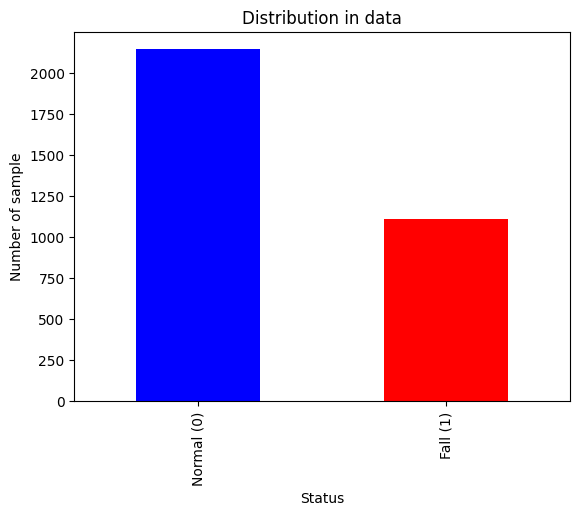

In [8]:
# prompt: nối các file keypoints_chute01.csv ... keypoints_chute04.csv

import pandas as pd
import glob

# Find all CSV files matching the pattern
csv_files = glob.glob('/content/drive/MyDrive/dataset/keypoints_chute*.csv')

# Create an empty list to store the dataframes
dfs = []

# Read each CSV file into a dataframe and append to the list
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all dataframes in the list
combined_df = pd.concat(dfs, ignore_index=True)

# Save the combined dataframe to a new CSV file (optional)
combined_df.to_csv('combined_keypoints.csv', index=False)

# Print the combined dataframe
combined_df

file_path = "/content/combined_keypoints.csv"

import matplotlib.pyplot as plt

# Kiểm tra cột nhãn (position_code hoặc tương tự)
if 'position_code' in df.columns:
    df['position_code'].value_counts().plot(kind='bar', color=['blue', 'red'])
    plt.xticks(ticks=[0, 1], labels=["Normal (0)", "Fall (1)"])
    plt.xlabel("Status")
    plt.ylabel("Number of sample")
    plt.title("Distribution in data")
    plt.show()
else:
    print("❌ Không tìm thấy cột nhãn 'position_code' trong dữ liệu!")




In [9]:
# Nội suy các giá trị NaN
df.interpolate(method='linear', inplace=True)

# Nếu vẫn còn NaN sau nội suy, điền bằng giá trị trung bình của cột đó
df.fillna(df.mean(), inplace=True)

# Kiểm tra lại xem còn giá trị NaN không
print("\n🔹 Kiểm tra lại số lượng giá trị NaN:")
print(df.isnull().sum().sum())  # Nếu kết quả là 0, dữ liệu đã sạch



🔹 Kiểm tra lại số lượng giá trị NaN:
0


In [10]:
from sklearn.preprocessing import MinMaxScaler

# Lấy các cột keypoints để chuẩn hóa
keypoints_columns = [col for col in df.columns if 'kp' in col]

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
df[keypoints_columns] = scaler.fit_transform(df[keypoints_columns])

# Kiểm tra lại kết quả chuẩn hóa
print("\n🔹 Kiểm tra dữ liệu sau chuẩn hóa:")
print(df[keypoints_columns].describe())



🔹 Kiểm tra dữ liệu sau chuẩn hóa:
            kp_0_x       kp_1_x       kp_2_x       kp_3_x       kp_4_x  \
count  4004.000000  4004.000000  4004.000000  4004.000000  4004.000000   
mean      0.245288     0.242892     0.206290     0.207398     0.273610   
std       0.307969     0.254134     0.277008     0.278700     0.306130   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.001429     0.244684     0.000000     0.000000     0.103635   
75%       0.513375     0.395152     0.449451     0.436637     0.567651   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

            kp_5_x       kp_6_x       kp_7_x       kp_8_x       kp_9_x  ...  \
count  4004.000000  4004.000000  4004.000000  4004.000000  4004.000000  ...   
mean      0.212571     0.243041     0.242817     0.293126     0.244039  ...   
std       0.272255     0.316917     0.285946     0.305828    

In [11]:
import numpy as np

# prompt: Từ file vừa chuẩn hóa, hãy tạo dữ liệu phù hợp để huấn luyện LSTM


def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length - 1):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Giả sử 'df' là DataFrame đã được xử lý và chuẩn hóa
# Lấy cột 'position_code' làm nhãn (y) và các cột keypoints làm dữ liệu đầu vào (X)
keypoints_columns = [col for col in df.columns if 'kp' in col]
X = df[keypoints_columns].values
y = df['position_code'].values

# Chia dữ liệu thành các chuỗi thời gian
seq_length = 20 # Ví dụ: độ dài chuỗi là 20
X_seq, y_seq = create_sequences(X, seq_length)

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_train = X_seq[:split_index]
y_train = y_seq[:split_index]
X_test = X_seq[split_index:]
y_test = y_seq[split_index:]

print("Shape of training data:", X_train.shape, y_train.shape)
print("Shape of testing data:", X_test.shape, y_test.shape)


Shape of training data: (3186, 20, 34) (3186, 34)
Shape of testing data: (797, 20, 34) (797, 34)


In [12]:
import numpy as np

sequence_length = 10  # Số khung hình liên tiếp trong mỗi chuỗi

# Lấy dữ liệu đầu vào và nhãn
features = df[keypoints_columns].values  # Chỉ lấy tọa độ keypoints
labels = df['position_code'].fillna(0).values  # Nhãn ngã (1) hoặc bình thường (0)

# Chuyển đổi thành chuỗi thời gian
X, y = [], []
for i in range(len(df) - sequence_length):
    X.append(features[i:i+sequence_length])  # Lấy 10 khung hình làm một chuỗi
    y.append(labels[i+sequence_length-1])  # Nhãn là frame cuối của chuỗi

X = np.array(X)
y = np.array(y)

# Kiểm tra kích thước dữ liệu
print("\n🔹 Kích thước của dữ liệu đầu vào:")
print("X.shape:", X.shape)  # (batch_size, sequence_length, feature_dim)
print("y.shape:", y.shape)  # (batch_size,)



🔹 Kích thước của dữ liệu đầu vào:
X.shape: (3994, 10, 34)
y.shape: (3994,)


In [13]:
np.savez("/content/drive/MyDrive/dataset/lstm_fall_data.npz", X=X, y=y)
print("✅ Dữ liệu đã được lưu thành công!")


✅ Dữ liệu đã được lưu thành công!


In [14]:
# Chuyển nhãn về nhị phân (0 hoặc 1)
y_cleaned = np.where(y >= 0.5, 1, 0)

# Kiểm tra lại sau khi làm sạch
unique, counts = np.unique(y_cleaned, return_counts=True)
print("\n🔹 Phân phối nhãn sau khi làm sạch:")
for u, c in zip(unique, counts):
    print(f"Giá trị {u}: {c} mẫu")



🔹 Phân phối nhãn sau khi làm sạch:
Giá trị 0: 2251 mẫu
Giá trị 1: 1743 mẫu


In [15]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành Train (80%), Validation (10%), Test (10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_cleaned, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Kiểm tra lại kích thước sau khi chia
print("\n🔹 Kích thước tập dữ liệu sau khi chia:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)



🔹 Kích thước tập dữ liệu sau khi chia:
X_train: (3195, 10, 34) y_train: (3195,)
X_val: (399, 10, 34) y_val: (399,)
X_test: (400, 10, 34) y_test: (400,)


Training fold 1...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - Precision: 0.3600 - Recall: 0.4018 - accuracy: 0.4319 - loss: 4.4595 - val_Precision: 0.4302 - val_Recall: 0.1182 - val_accuracy: 0.5480 - val_loss: 4.0816 - learning_rate: 5.0000e-05
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - Precision: 0.4759 - Recall: 0.5403 - accuracy: 0.5317 - loss: 4.1950 - val_Precision: 0.5977 - val_Recall: 0.5080 - val_accuracy: 0.6370 - val_loss: 3.9484 - learning_rate: 5.0000e-05
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - Precision: 0.5094 - Recall: 0.5903 - accuracy: 0.5793 - loss: 3.9967 - val_Precision: 0.6177 - val_Recall: 0.5783 - val_accuracy: 0.6606 - val_loss: 3.7858 - learning_rate: 5.0000e-05
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - Precision: 0.5479 - Recall: 0.6299 - accuracy: 0.6088 - loss: 3.8409 - val_Precision: 0.7655 - val_Recall: 0.7508 - val_accuracy: 0.7914 - val_loss: 3.6106 - learning_rate: 5.0000e-05
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - Preci

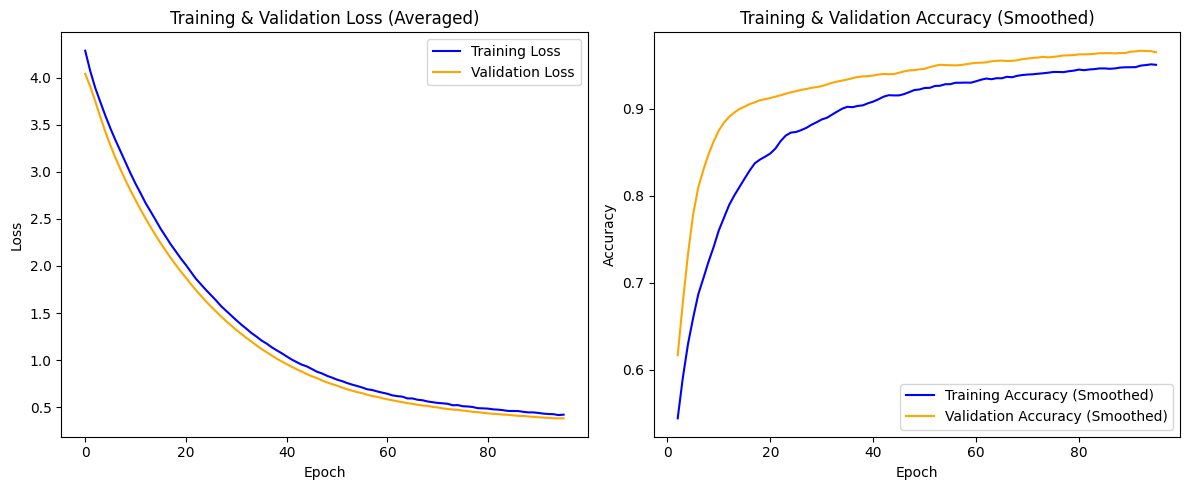

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - Precision: 0.3656 - Recall: 0.4314 - accuracy: 0.4371 - loss: 4.5657 - learning_rate: 5.0000e-05
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: Precision,Recall,accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: Precision,Recall,accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - Precision: 0.4309 - Recall: 0.5058 - accuracy: 0.5046 - loss: 4.2732 - learning_rate: 5.0000e-05
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - Precision: 0.4803 - Recall: 0.5595 - accuracy: 0.5550 - loss: 4.0728 - learning_rate: 5.0000e-05
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - Precision: 0.5337 - Recall: 0.6107 - accuracy: 0.5922 - loss: 3.8992 - learning_rate: 5.0000e-05
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - Precision: 0.5664 - Recall: 0.6449 - accuracy: 0.6390 - loss: 3.7329 - learning_rate: 5.0000e-05
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - Precision: 0.5588 - Recall: 0.6411 - accuracy: 0.6330 - loss: 3.6208 - learning_rate: 5.0000e-05
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - Precision: 0.5883 - Recall: 0.6588 - accuracy: 0.6599 - loss: 3.4358 - learning_rate: 5.0000e-05
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - Precision: 0.6486 - Recall: 0.7251 - a

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import pandas as pd  # Thêm pandas để lưu file CSV

# Giả định dữ liệu: X_train, X_val, y_train, y_val đã có
# X_train.shape = (samples, timesteps, features)
# y_train.shape = (samples,) hoặc (samples, 1) cho bài toán phân loại nhị phân

# 1. Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape)

# 2. Xử lý mất cân bằng dữ liệu
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# 3. Xây dựng mô hình LSTM
def build_model(input_shape):
    model = Sequential([
        # Tầng Bidirectional LSTM đầu tiên
        Bidirectional(LSTM(units=16, return_sequences=True,
                           kernel_regularizer=l2(0.02),
                           input_shape=input_shape)),
        Dropout(0.3),  # Tăng Dropout để giảm overfitting
        BatchNormalization(),  # Thêm BatchNormalization để ổn định huấn luyện

        # Tầng Bidirectional LSTM thứ hai
        Bidirectional(LSTM(units=16, kernel_regularizer=l2(0.02))),
        Dropout(0.3),
        BatchNormalization(),

        # Tầng Dense đầu ra (phân loại nhị phân)
        Dense(units=1, activation='sigmoid')
    ])
    return model

# 4. Định nghĩa hyperparameters
input_shape = (X_train.shape[1], X_train.shape[2])
epochs = 100
batch_size = 32
learning_rate = 0.00005  # Giảm learning rate để huấn luyện ổn định hơn

# 5. Sử dụng K-Fold Cross Validation để thu thập training và validation metrics
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
val_accuracies = []
val_losses = []
train_losses_per_fold = []
train_accuracies_per_fold = []
val_losses_per_fold = []
val_accuracies_per_fold = []

# Kết hợp X_train và X_val để cross-validation
X = np.concatenate((X_train_scaled, X_val_scaled), axis=0)
y = np.concatenate((y_train, y_val), axis=0)

for train_index, val_index in kf.split(X):
    print(f'Training fold {fold_no}...')
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Xây dựng và biên dịch mô hình
    model = build_model(input_shape)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'Precision', 'Recall'])

    # Định nghĩa callbacks
    early_stopping = EarlyStopping(monitor="val_loss",
                                   patience=3,
                                   min_delta=0.001,
                                   restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                  factor=0.5,
                                  patience=2,
                                  min_lr=1e-6)

    # Huấn luyện mô hình
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Lưu lại training và validation metrics cho fold này
    train_losses_per_fold.append(history.history['loss'])
    train_accuracies_per_fold.append(history.history['accuracy'])
    val_losses_per_fold.append(history.history['val_loss'])
    val_accuracies_per_fold.append(history.history['val_accuracy'])

    # Đánh giá trên tập validation của fold này
    val_loss, val_accuracy, val_precision, val_recall = model.evaluate(X_val_fold, y_val_fold)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f'Fold {fold_no} - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    fold_no += 1

# In kết quả trung bình của cross-validation
print(f'Average Validation Loss: {np.mean(val_losses):.4f} (+/- {np.std(val_losses):.4f})')
print(f'Average Validation Accuracy: {np.mean(val_accuracies):.4f} (+/- {np.std(val_accuracies):.4f})')

# 6. Tính trung bình training và validation metrics qua các fold
# Đảm bảo các fold có cùng số lượng epochs (lấy số epochs nhỏ nhất)
min_epochs = min(len(train_loss) for train_loss in train_losses_per_fold)
train_losses_avg = np.mean([train_loss[:min_epochs] for train_loss in train_losses_per_fold], axis=0)
val_losses_avg = np.mean([val_loss[:min_epochs] for val_loss in val_losses_per_fold], axis=0)
train_accuracies_avg = np.mean([train_acc[:min_epochs] for train_acc in train_accuracies_per_fold], axis=0)
val_accuracies_avg = np.mean([val_acc[:min_epochs] for val_acc in val_accuracies_per_fold], axis=0)

# 7. Lưu số liệu vào file CSV
metrics_df = pd.DataFrame({
    'epoch': range(min_epochs),
    'train_loss': train_losses_avg,
    'val_loss': val_losses_avg,
    'train_accuracy': train_accuracies_avg,
    'val_accuracy': val_accuracies_avg
})
metrics_df.to_csv('training_metrics.csv', index=False)
print("Đã lưu số liệu vào file 'training_metrics.csv'")

# 8. Làm mịn Accuracy bằng Moving Average
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_size = 3
train_accuracy_smoothed = moving_average(train_accuracies_avg, window_size)
val_accuracy_smoothed = moving_average(val_accuracies_avg, window_size)

# Điều chỉnh số lượng epochs cho dữ liệu đã làm mịn
epochs_smoothed = range(window_size-1, len(train_accuracies_avg))

# 9. Vẽ đồ thị Training & Validation Loss và Accuracy
plt.figure(figsize=(12, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses_avg, label='Training Loss', color='blue')
plt.plot(val_losses_avg, label='Validation Loss', color='orange')
plt.title('Training & Validation Loss (Averaged)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Đồ thị Accuracy (đã làm mịn)
plt.subplot(1, 2, 2)
plt.plot(epochs_smoothed, train_accuracy_smoothed, label='Training Accuracy (Smoothed)', color='blue')
plt.plot(epochs_smoothed, val_accuracy_smoothed, label='Validation Accuracy (Smoothed)', color='orange')
plt.title('Training & Validation Accuracy (Smoothed)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 10. Huấn luyện lại mô hình trên toàn bộ dữ liệu (X_train + X_val) để sử dụng cuối cùng
model = build_model(input_shape)
model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall'])

history = model.fit(
    X, y,
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 11. Đánh giá mô hình trên tập test (nếu có)
# Nếu bạn có tập test riêng (X_test, y_test), bạn có thể đánh giá ở đây
val_loss, val_accuracy, val_precision, val_recall = model.evaluate(X_test, y_test)
print(f"Test Loss: {val_loss:.4f}")
print(f"Test Accuracy: {val_accuracy:.4f}")
print(f"Test Precision: {val_precision:.4f}")
print(f"Test Recall: {val_recall:.4f}")

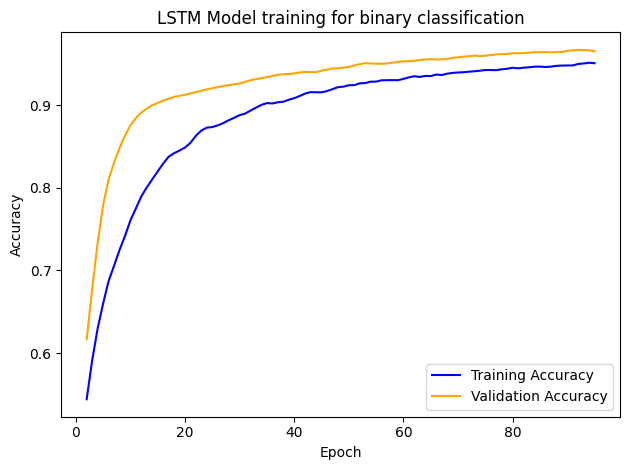

In [17]:

plt.plot(epochs_smoothed, train_accuracy_smoothed, label='Training Accuracy', color='blue')
plt.plot(epochs_smoothed, val_accuracy_smoothed, label='Validation Accuracy', color='orange')
plt.title('LSTM Model training for binary classification')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_accuracy.jpg', dpi=900)
plt.show()


In [18]:
from tensorflow.keras.models import save_model

# Lưu mô hình chuẩn định dạng HDF5
model.save("/content/lstm_fall_model.h5", save_format="h5")



In [19]:
import tensorflow as tf
import numpy as np

# Load model
model = tf.keras.models.load_model("/content/lstm_fall_model.h5")

# Dự đoán từ dữ liệu mẫu
def predict_fall(X_sample):
    prediction = model.predict(np.expand_dims(X_sample, axis=0))
    return "Fall" if prediction[0] > 0.5 else "No Fall"

# Test dự đoán trên một mẫu
X_test_sample = np.random.rand(10, 34)  # Thay thế bằng dữ liệu thực tế
print(predict_fall(X_test_sample))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
No Fall


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
import importlib
import ultralytics.nn.modules.block
import ultralytics.nn.tasks


# Load mô hình YOLOv8 Pose và LSTM
yolo_model = YOLO("/content/best.pt")  # Thay bằng model đã train nếu có
lstm_model = tf.keras.models.load_model("/content/lstm_fall_model.h5", compile=False)

# Số lượng keypoints cố định (ví dụ: 17 điểm với mỗi điểm có (x, y))
NUM_KEYPOINTS = 17 * 2  # 34 giá trị đầu vào

# Biến đếm số lần liên tiếp dự đoán "Fall"
fall_count = 0
FALL_THRESHOLD = 8  # Ngưỡng để xác nhận ngã

# Danh sách đường nối giữa các keypoints (skeleton connections) theo chuẩn COCO
SKELETON_CONNECTIONS = [
    (5, 7), (7, 9),  # Tay trái
    (6, 8), (8, 10),  # Tay phải
    (5, 6), (5, 11), (6, 12),  # Vai và thân
    (11, 12), (11, 13), (13, 15),  # Chân trái
    (12, 14), (14, 16)  # Chân phải
]

# Hàm chọn người phù hợp (chọn người gần trung tâm nhất)
def select_main_person(keypoints_list):
    if not keypoints_list:
        return None
    elif len(keypoints_list) == 1:
        return keypoints_list[0].flatten()

    # Tính khoảng cách từ trung tâm ảnh đến từng người
    center_x, center_y = 320, 240  # Giả định frame có kích thước 640x480
    distances = [np.linalg.norm(np.mean(kp, axis=0) - np.array([center_x, center_y])) for kp in keypoints_list]

    # Chọn người có khoảng cách gần nhất với trung tâm
    best_idx = np.argmin(distances)
    return keypoints_list[best_idx].flatten()

# Hàm trích xuất keypoints từ frame video
def extract_keypoints_from_frame(frame):
    results = yolo_model(frame)
    keypoints_list = [r.keypoints.xy.cpu().numpy() for r in results if r.keypoints]

    selected_keypoints = select_main_person(keypoints_list)

    if selected_keypoints is not None:
        # Kiểm tra số lượng keypoints, nếu thiếu thì padding 0, nếu thừa thì cắt bớt
        if selected_keypoints.shape[0] < NUM_KEYPOINTS:
            selected_keypoints = np.pad(selected_keypoints, (0, NUM_KEYPOINTS - selected_keypoints.shape[0]), mode='constant')
        else:
            selected_keypoints = selected_keypoints[:NUM_KEYPOINTS]  # Cắt bớt nếu dư
    else:
        selected_keypoints = np.zeros(NUM_KEYPOINTS)  # Nếu không phát hiện người, gán toàn bộ là 0

    return selected_keypoints

# Hàm dự đoán từ keypoints
def predict_fall(X_sample):
    X_sample = np.expand_dims(X_sample, axis=0)  # Thêm chiều batch
    prediction = lstm_model.predict(X_sample)
    return "No Fall" if prediction[0] > 0.5 else "Fall"

# Hàm vẽ keypoints và skeleton lên người
def draw_keypoints_and_skeleton(frame, keypoints):
    keypoints = keypoints.reshape((NUM_KEYPOINTS // 2, 2))  # Chuyển về dạng (17, 2)
    for (x, y) in keypoints:
        if x > 0 and y > 0:  # Kiểm tra keypoint hợp lệ
            cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 255), -1)  # Vẽ keypoint

    # Vẽ các đường nối giữa các keypoints (skeleton)
    for (i, j) in SKELETON_CONNECTIONS:
        if all(keypoints[idx, 0] > 0 and keypoints[idx, 1] > 0 for idx in (i, j)):  # Kiểm tra hợp lệ
            pt1 = (int(keypoints[i, 0]), int(keypoints[i, 1]))
            pt2 = (int(keypoints[j, 0]), int(keypoints[j, 1]))
            cv2.line(frame, pt1, pt2, (255, 255, 255), 2)

# Xử lý video và gán nhãn
def process_video(input_video, output_video):
    global fall_count  # Sử dụng biến toàn cục để lưu trạng thái
    cap = cv2.VideoCapture(input_video)
    fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Định dạng video
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    sequence = []
    final_label = "No Fall"  # Nhãn hiển thị trên video

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        keypoints = extract_keypoints_from_frame(frame)
        sequence.append(keypoints)

        if len(sequence) > 10:
            sequence.pop(0)  # Giữ lại 10 frame gần nhất

        if len(sequence) == 10:  # Khi đủ 10 frame, thực hiện dự đoán
            X_input = np.array(sequence)  # Đảm bảo định dạng đồng nhất
            result = predict_fall(X_input)

            # Kiểm tra số lần liên tiếp dự đoán "Fall"
            if result == "Fall":
                fall_count += 1
                if fall_count >= FALL_THRESHOLD:
                    final_label = "Fall"  # Chỉ xác nhận ngã khi đạt ngưỡng
            else:
                fall_count = 0  # Reset nếu phát hiện "No Fall"
                final_label = "No Fall"

            # Vẽ keypoints và skeleton lên frame
            draw_keypoints_and_skeleton(frame, keypoints)

            # Vẽ nhãn lên frame
            label_color = (0, 0, 255) if final_label == "Fall" else (0, 255, 0)
            cv2.putText(frame, final_label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX,
                        1, label_color, 2, cv2.LINE_AA)

        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ Video đã được lưu tại: {output_video}")

# Chạy chương trình với video đầu vào
input_video = "/content/drive/MyDrive/dataset/chute10/cam5.avi"
output_video = "/content/output_fall_detected.avi"
process_video(input_video, output_video)


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
import importlib
import ultralytics.nn.modules.block
import ultralytics.nn.tasks


# Load mô hình YOLOv8 Pose và LSTM
yolo_model = YOLO("/content/bes.pt")  # Thay bằng model đã train nếu có
lstm_model = tf.keras.models.load_model("/content/lstm_fall_model.h5", compile=False)

# Force the model to run on CPU
with tf.device('/CPU:0'):  # This line forces execution on the CPU
    # Instead of trying to set the inputs manually, you can try to force the model to predict
    # on the CPU using tf.device, or using the 'experimental_relax_shapes=True' argument to
    # tf.function.
    # for layer in lstm_model.layers:
    #     if isinstance(layer, tf.keras.layers.LSTM) or isinstance(layer, tf.keras.layers.Bidirectional):
    #         # This can help with compatibility issues between TF versions
    #         layer.call = tf.function(layer.call, experimental_relax_shapes=True)

    # Số lượng keypoints cố định (ví dụ: 17 điểm với mỗi điểm có (x, y))
    NUM_KEYPOINTS = 17 * 2  # 34 giá trị đầu vào

    # Biến đếm số lần liên tiếp dự đoán "Fall"
    fall_count = 0
    FALL_THRESHOLD = 8  # Ngưỡng để xác nhận ngã

    # Danh sách đường nối giữa các keypoints (skeleton connections) theo chuẩn COCO
    SKELETON_CONNECTIONS = [
        (5, 7), (7, 9),  # Tay trái
        (6, 8), (8, 10),  # Tay phải
        (5, 6), (5, 11), (6, 12),  # Vai và thân
        (11, 12), (11, 13), (13, 15),  # Chân trái
        (12, 14), (14, 16)  # Chân phải
    ]

    # ... (rest of the code remains the same)

# Hàm chọn người phù hợp (chọn người gần trung tâm nhất)
def select_main_person(keypoints_list):
    if not keypoints_list:
        return None
    elif len(keypoints_list) == 1:
        return keypoints_list[0].flatten()

    # Tính khoảng cách từ trung tâm ảnh đến từng người
    center_x, center_y = 320, 240  # Giả định frame có kích thước 640x480
    distances = [np.linalg.norm(np.mean(kp, axis=0) - np.array([center_x, center_y])) for kp in keypoints_list]

    # Chọn người có khoảng cách gần nhất với trung tâm
    best_idx = np.argmin(distances)
    return keypoints_list[best_idx].flatten()

# Hàm trích xuất keypoints từ frame video
def extract_keypoints_from_frame(frame):
    results = yolo_model(frame)
    keypoints_list = [r.keypoints.xy.cpu().numpy() for r in results if r.keypoints]

    selected_keypoints = select_main_person(keypoints_list)

    if selected_keypoints is not None:
        # Kiểm tra số lượng keypoints, nếu thiếu thì padding 0, nếu thừa thì cắt bớt
        if selected_keypoints.shape[0] < NUM_KEYPOINTS:
            selected_keypoints = np.pad(selected_keypoints, (0, NUM_KEYPOINTS - selected_keypoints.shape[0]), mode='constant')
        else:
            selected_keypoints = selected_keypoints[:NUM_KEYPOINTS]  # Cắt bớt nếu dư
    else:
        selected_keypoints = np.zeros(NUM_KEYPOINTS)  # Nếu không phát hiện người, gán toàn bộ là 0

    return selected_keypoints

# Hàm dự đoán từ keypoints
def predict_fall(X_sample):
    X_sample = np.expand_dims(X_sample, axis=0)  # Thêm chiều batch
    prediction = lstm_model.predict(X_sample)
    return "No Fall" if prediction[0] > 0.5 else "Fall"

# Hàm vẽ keypoints và skeleton lên người
def draw_keypoints_and_skeleton(frame, keypoints):
    keypoints = keypoints.reshape((NUM_KEYPOINTS // 2, 2))  # Chuyển về dạng (17, 2)
    for (x, y) in keypoints:
        if x > 0 and y > 0:  # Kiểm tra keypoint hợp lệ
            cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 255), -1)  # Vẽ keypoint

    # Vẽ các đường nối giữa các keypoints (skeleton)
    for (i, j) in SKELETON_CONNECTIONS:
        if all(keypoints[idx, 0] > 0 and keypoints[idx, 1] > 0 for idx in (i, j)):  # Kiểm tra hợp lệ
            pt1 = (int(keypoints[i, 0]), int(keypoints[i, 1]))
            pt2 = (int(keypoints[j, 0]), int(keypoints[j, 1]))
            cv2.line(frame, pt1, pt2, (255, 255, 255), 2)

# Xử lý video và gán nhãn
def process_video(input_video, output_video):
    global fall_count  # Sử dụng biến toàn cục để lưu trạng thái
    cap = cv2.VideoCapture(input_video)
    fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Định dạng video
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    sequence = []
    final_label = "No Fall"  # Nhãn hiển thị trên video

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        keypoints = extract_keypoints_from_frame(frame)
        sequence.append(keypoints)

        if len(sequence) > 10:
            sequence.pop(0)  # Giữ lại 10 frame gần nhất

        if len(sequence) == 10:  # Khi đủ 10 frame, thực hiện dự đoán
            X_input = np.array(sequence)  # Đảm bảo định dạng đồng nhất
            result = predict_fall(X_input)

            # Kiểm tra số lần liên tiếp dự đoán "Fall"
            if result == "Fall":
                fall_count += 1
                if fall_count >= FALL_THRESHOLD:
                    final_label = "Fall"  # Chỉ xác nhận ngã khi đạt ngưỡng
            else:
                fall_count = 0  # Reset nếu phát hiện "No Fall"
                final_label = "No Fall"

            # Vẽ keypoints và skeleton lên frame
            draw_keypoints_and_skeleton(frame, keypoints)

            # Vẽ nhãn lên frame
            label_color = (0, 0, 255) if final_label == "Fall" else (0, 255, 0)
            cv2.putText(frame, final_label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX,
                        1, label_color, 2, cv2.LINE_AA)

        out.write(frame)

    cap.release()
    out.release()
    print(f"✅ Video đã được lưu tại: {output_video}")

# Chạy chương trình với video đầu vào
input_video = "/content/drive/MyDrive/dataset/chute10/cam5.avi"
output_video = "/content/output_fall_detected.avi"
process_video(input_video, output_video)


0: 448x640 1 person, 213.0ms
Speed: 5.5ms preprocess, 213.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 183.0ms
Speed: 4.0ms preprocess, 183.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 173.8ms
Speed: 4.0ms preprocess, 173.8ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 180.5ms
Speed: 3.8ms preprocess, 180.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 190.1ms
Speed: 4.0ms preprocess, 190.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 358.8ms
Speed: 10.5ms preprocess, 358.8ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 358.5ms
Speed: 4.1ms preprocess, 358.5ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 266.0ms
Speed: 5.1ms preprocess, 266.0ms inference, 1.3ms postprocess per image a